# foundations/04: Data Pipeline

This notebook demonstrates how to generate, inspect, and load training datasets using the `crn_surrogate.data` sub-packages.

**Contents:**
1. CRNCollator and Batching — padding mixed-size CRNs for batching
2. DataGenerationPipeline — end-to-end: sample → simulate → curate → save
3. Dataset Inspection — load the generated dataset, print statistics
4. Diversity Visualizations — confirm the dataset covers diverse dynamical regimes
5. Saving and Loading — torch.save/load, CRNTrajectoryDataset from file
6. Full-Scale Dataset — note on production-scale generation

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

from _shared.plotting import setup_style

setup_style()

import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

TAB10 = plt.rcParams["axes.prop_cycle"].by_key()["color"]

## 1. CRNCollator and Batching

CRNs in the dataset have different numbers of species and reactions. `CRNCollator` pads stoichiometry, trajectory, and mask tensors to the maximum sizes in each batch, enabling standard mini-batch training.

With the M-trajectory structure, `batch["trajectories"]` has shape `(B, M, T, max_species)`.

In [2]:
from crn_surrogate.data.generation.reference_crns import birth_death, lotka_volterra, schlogl
from crn_surrogate.data.dataset import CRNTrajectoryDataset, TrajectoryItem, CRNCollator
from crn_surrogate.simulation import GillespieSSA, Trajectory
from crn_surrogate.encoder.tensor_repr import crn_to_tensor_repr

ssa = GillespieSSA()

T_MAX = 20.0
N_GRID = 50
M = 16
time_grid = torch.linspace(0.0, T_MAX, N_GRID)

crn_configs = [
    (birth_death(k_birth=2.0, k_death=0.5), torch.tensor([0.0]),        "Birth-Death"),
    (birth_death(k_birth=5.0, k_death=1.0), torch.tensor([3.0]),        "Birth-Death (fast)"),
    (lotka_volterra(),                       torch.tensor([80.0, 30.0]), "Lotka-Volterra"),
    (schlogl(),                              torch.tensor([30.0]),       "Schlögl"),
]

items = []
for crn_def, init, name in crn_configs:
    crn_repr = crn_to_tensor_repr(crn_def)
    for _ in range(10):
        trajs = Trajectory.stack_on_grid(
            ssa.simulate_batch(
                stoichiometry=crn_def.stoichiometry_matrix,
                propensity_fn=crn_def.evaluate_propensities,
                initial_state=init.clone(),
                t_max=T_MAX,
                n_trajectories=M,
                n_workers=1,
            ),
            time_grid,
        )  # (M, T, n_species)
        items.append(TrajectoryItem(
            crn_repr=crn_repr,
            initial_state=init.clone(),
            trajectories=trajs,
            times=time_grid,
        ))
    print(f"  {name}: 10 items × {M} SSA runs = {10 * M} trajectories")

dataset = CRNTrajectoryDataset(items)
print(f"\nDataset: {len(dataset)} items")

  Birth-Death: 10 items × 16 SSA runs = 160 trajectories


  Birth-Death (fast): 10 items × 16 SSA runs = 160 trajectories


  Lotka-Volterra: 10 items × 16 SSA runs = 160 trajectories


  Schlögl: 10 items × 16 SSA runs = 160 trajectories

Dataset: 40 items


In [3]:
collator = CRNCollator()
loader = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=collator)

batch = next(iter(loader))

print("Batch contents:")
for key, val in batch.items():
    if isinstance(val, torch.Tensor):
        print(f"  {key:<25}: shape={tuple(val.shape)}, dtype={val.dtype}")
    else:
        print(f"  {key:<25}: {val}")

B, M_out, T_out, S_out = batch["trajectories"].shape
print(f"\ntrajectories: B={B}, M={M_out}, T={T_out}, max_species={S_out}")
print(f"\nspecies_mask (True = real species):\n{batch['species_mask']}")
print(f"\nreaction_mask (True = real reaction):\n{batch['reaction_mask']}")

Batch contents:
  stoichiometry            : shape=(4, 4, 2), dtype=torch.float32
  dependency_matrix        : shape=(4, 4, 2), dtype=torch.float32
  propensity_params        : shape=(4, 4, 8), dtype=torch.float32
  propensity_type_ids      : shape=(4, 4), dtype=torch.int64
  initial_states           : shape=(4, 2), dtype=torch.float32
  trajectories             : shape=(4, 16, 50, 2), dtype=torch.float32
  times                    : shape=(4, 50), dtype=torch.float32
  species_mask             : shape=(4, 2), dtype=torch.bool
  reaction_mask            : shape=(4, 4), dtype=torch.bool
  cluster_ids              : shape=(4,), dtype=torch.int64
  input_protocols          : [InputProtocol(schedules={}), InputProtocol(schedules={}), InputProtocol(schedules={}), InputProtocol(schedules={})]
  internal_species_mask    : None
  scales                   : None
  crn_reprs                : [CRNTensorRepr(stoichiometry=tensor([[ 1.],
        [-1.],
        [ 1.],
        [-1.]]), dependency_mat

## 2. DataGenerationPipeline

The `DataGenerationPipeline` runs the full data generation loop:
1. Sample kinetic parameters for each motif
2. Simulate M SSA trajectories
3. Check viability (6 criteria)
4. Save viable items to disk

For demonstration we use reduced counts (30 samples per motif, 8 SSA trajectories). This produces a dataset in a few minutes.

In [4]:
import logging
import time
from pathlib import Path
from crn_surrogate.data.generation import (
    DataGenerationPipeline,
    GenerationConfig,
    SamplingConfig,
    CurationConfig,
    all_elementary_tasks,
)

FORCE_REGENERATE = False  # Set to True to regenerate even if dataset exists

logging.basicConfig(level=logging.WARNING, format="%(levelname)s  %(name)s  %(message)s")

config = GenerationConfig(
    sampling=SamplingConfig(random_seed=42),
    curation=CurationConfig(),
    n_ssa_trajectories=8,
    simulation_time=50.0,
    n_timepoints=100,
    batch_size=16,
    max_attempts_multiplier=5,
    output_dir="../data_cache/demo_dataset",
    random_seed=42,
)

_dataset_path = Path(config.output_dir) / "dataset.pt"

if not FORCE_REGENERATE and _dataset_path.exists():
    print(f"Dataset already exists at {_dataset_path} \u2014 skipping generation.")
    print("Set FORCE_REGENERATE = True to regenerate from scratch.")
    summary = None
else:
    tasks = all_elementary_tasks(target_per_motif=30)
    pipeline = DataGenerationPipeline(config, tasks=tasks)
    t0 = time.time()
    summary = pipeline.run()
    elapsed = time.time() - t0
    print(f"Generation complete in {elapsed:.1f}s")
    print(f"Total viable items: {summary.total_items}")

Dataset already exists at ../data_cache/demo_dataset/dataset.pt — skipping generation.
Set FORCE_REGENERATE = True to regenerate from scratch.


## 3. Dataset Inspection

After generation, load the dataset and verify its structure: shapes, finiteness, metadata, and per-motif counts.

In [5]:
import collections
import json as _json
from crn_surrogate.data.generation.pipeline import DatasetSummary

_dataset_path = Path("../data_cache/demo_dataset/dataset.pt")

# Load summary from metadata.json if pipeline was not re-run
if summary is None:
    _meta_path = _dataset_path.parent / "metadata.json"
    with open(_meta_path) as _f:
        _meta = _json.load(_f)
    summary = DatasetSummary(
        total_items=_meta["total_items"],
        counts_per_motif=_meta["counts_per_motif"],
        curation_stats=_meta["curation_stats"],
        cluster_id_map=_meta["cluster_id_map"],
    )

generated_dataset = CRNTrajectoryDataset(_dataset_path)
print(f"Dataset loaded: {len(generated_dataset)} items")

errors = []
for i, item in enumerate(generated_dataset):
    M_i, T_i, S_i = item.trajectories.shape
    if S_i != item.crn_repr.n_species:
        errors.append(f"Item {i}: trajectory species {S_i} != crn_repr.n_species {item.crn_repr.n_species}")
    if not torch.isfinite(item.trajectories).all():
        errors.append(f"Item {i}: trajectories contain non-finite values")
    if not item.motif_label:
        errors.append(f"Item {i}: empty motif_label")

if errors:
    print(f"FAILED \u2014 {len(errors)} error(s) found:")
    for e in errors[:10]:
        print(f"  x {e}")
else:
    print("All shape / finiteness / metadata checks passed.")

counts = collections.Counter(item.motif_label for item in generated_dataset)
print(f"\n{'Motif':<40} {'Count':>6}")
print("-" * 48)
for label, count in sorted(counts.items()):
    print(f"{label:<40} {count:>6}")

item0 = generated_dataset[0]
traj = item0.trajectories
print(f"\nSample item \u2014 motif: {item0.motif_label!r}")
print(f"  trajectories shape : {tuple(traj.shape)}  (M, T, n_species)")
print(f"  times              : {item0.times[0]:.1f} -> {item0.times[-1]:.1f}")
print(f"  trajectory mean    : {traj.mean():.3f}")
print(f"  trajectory std     : {traj.std():.3f}")

Dataset loaded: 240 items
All shape / finiteness / metadata checks passed.

Motif                                     Count
------------------------------------------------
auto_catalysis                               30
birth_death                                  30
enzymatic_catalysis                          30
incoherent_feedforward                       30
negative_autoregulation                      30
repressilator                                30
substrate_inhibition                         30
toggle_switch                                30

Sample item — motif: 'birth_death'
  trajectories shape : (8, 100, 1)  (M, T, n_species)
  times              : 0.0 -> 50.0
  trajectory mean    : 244.967
  trajectory std     : 127.679


In [6]:
print("\nCuration statistics per motif:")
print(f"  {'Motif':<35} {'Sampled':>8} {'Passed':>8} {'Pass %':>8}  Rejection breakdown")
print("  " + "-" * 80)
for label, stats in summary.curation_stats.items():
    n = stats["n_sampled"]
    p = stats["n_passed"]
    rate = 100 * p / n if n > 0 else 0.0
    rejections = {k: v for k, v in stats.items()
                  if k not in ("n_sampled", "n_passed", "n_rejected") and v > 0}
    rej_str = ", ".join(f"{k}={v}" for k, v in rejections.items()) if rejections else "\u2014"
    print(f"  {label:<35} {n:>8} {p:>8} {rate:>7.0f}%  {rej_str}")


Curation statistics per motif:
  Motif                                Sampled   Passed   Pass %  Rejection breakdown
  --------------------------------------------------------------------------------
  birth_death                               30       30     100%  —
  auto_catalysis                            32       30      94%  zero_stuck=2
  negative_autoregulation                   30       30     100%  —
  toggle_switch                             30       30     100%  —
  enzymatic_catalysis                       30       30     100%  —
  incoherent_feedforward                    30       30     100%  —
  repressilator                             30       30     100%  —
  substrate_inhibition                      30       30     100%  —


## 4. Diversity Visualizations

We visualize the dataset to confirm it covers diverse dynamical regimes across motifs and parameter configurations.

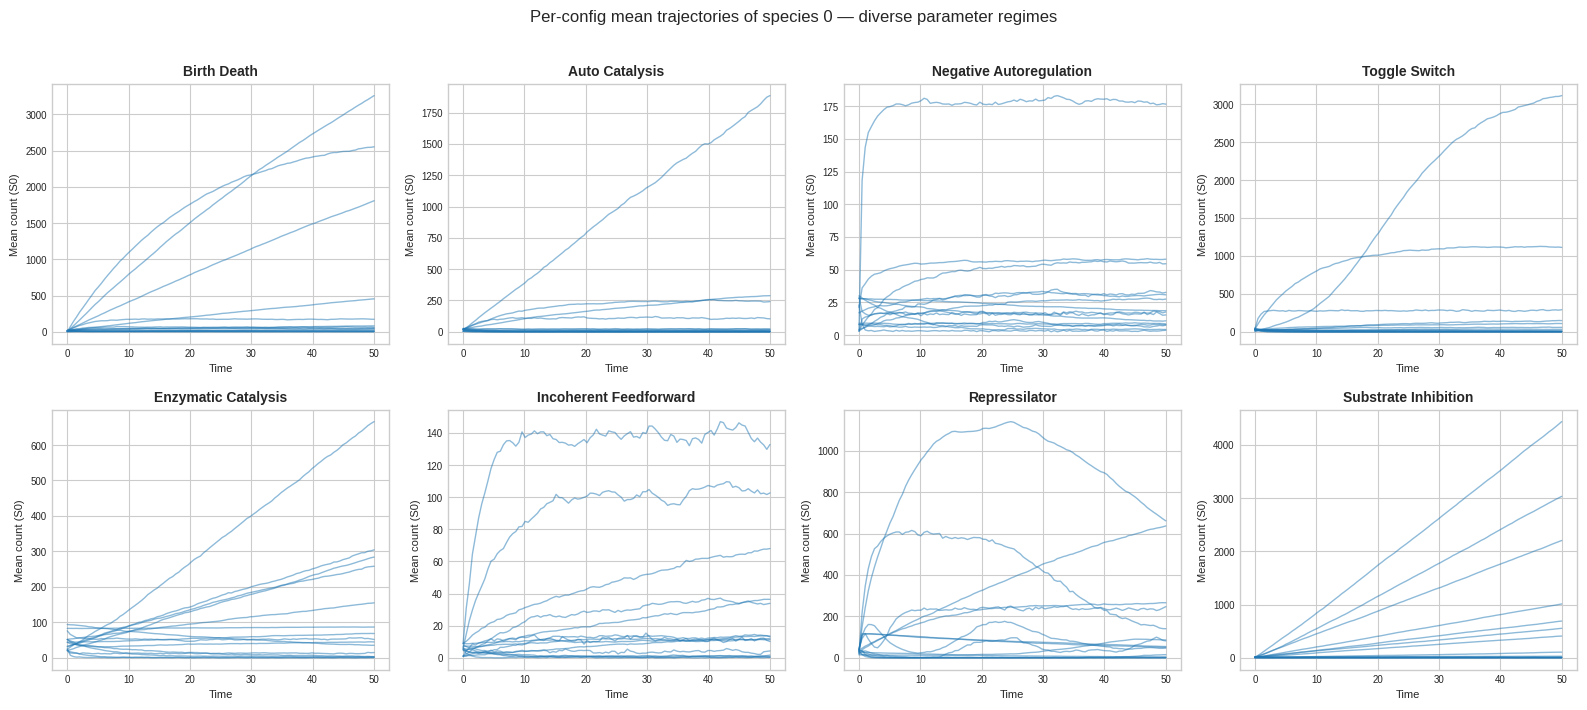

In [7]:
by_label = {}
for item in generated_dataset:
    by_label.setdefault(item.motif_label, []).append(item)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes_flat = axes.flatten()

for ax, (label, label_items) in zip(axes_flat, by_label.items()):
    t = label_items[0].times.numpy()
    for item in label_items[:15]:
        mean_traj = item.trajectories[:, :, 0].mean(dim=0).numpy()
        ax.plot(t, mean_traj, alpha=0.5, lw=1.0, color=TAB10[0])
    ax.set_title(label.replace("_", " ").title(), fontsize=10, fontweight="bold")
    ax.set_xlabel("Time", fontsize=8)
    ax.set_ylabel("Mean count (S0)", fontsize=8)
    ax.tick_params(labelsize=7)

for ax in axes_flat[len(by_label):]:
    ax.set_visible(False)

plt.suptitle(
    "Per-config mean trajectories of species 0 \u2014 diverse parameter regimes",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.show()

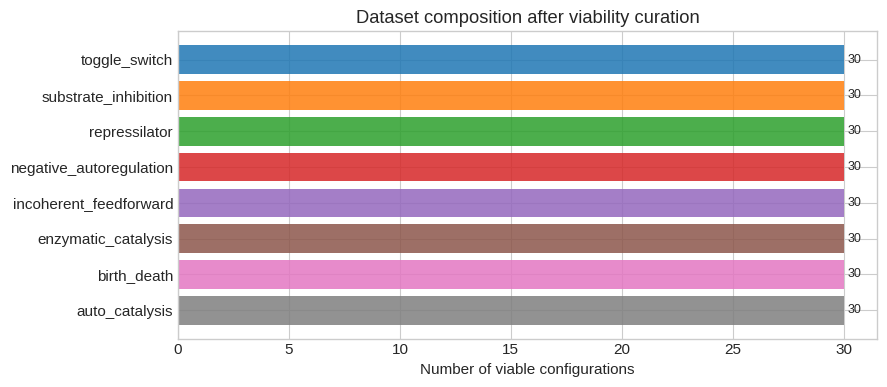

In [8]:
# Bar chart of motif composition
labels = list(summary.counts_per_motif.keys())
counts_list = list(summary.counts_per_motif.values())
sorted_pairs = sorted(zip(counts_list, labels), reverse=True)
counts_s, labels_s = zip(*sorted_pairs)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(labels_s, counts_s,
               color=[TAB10[i % 10] for i in range(len(labels_s))], alpha=0.85)
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel("Number of viable configurations")
ax.set_title("Dataset composition after viability curation")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Saving and Loading

The `DataGenerationPipeline` automatically saves the dataset to disk. To load it back in a training script, pass the `.pt` file path to `CRNTrajectoryDataset`.

In [9]:
# Loading from file path
loaded = CRNTrajectoryDataset("../data_cache/demo_dataset/dataset.pt")
print(f"Loaded dataset size: {len(loaded)} items")

item = loaded[0]
print(f"\nFirst item:")
print(f"  motif_label:          {item.motif_label}")
print(f"  n_species:            {item.crn_repr.n_species}")
print(f"  n_reactions:          {item.crn_repr.n_reactions}")
print(f"  trajectories shape:   {item.trajectories.shape}  (M, T, n_species)")
print(f"  times shape:          {item.times.shape}")

# Using with DataLoader
collator = CRNCollator()
loader = DataLoader(loaded, batch_size=4, shuffle=True, collate_fn=collator)
batch = next(iter(loader))
print(f"\nBatch trajectories shape: {tuple(batch['trajectories'].shape)}  (B, M, T, max_species)")

Loaded dataset size: 240 items

First item:
  motif_label:          birth_death
  n_species:            1
  n_reactions:          2
  trajectories shape:   torch.Size([8, 100, 1])  (M, T, n_species)
  times shape:          torch.Size([100])

Batch trajectories shape: (4, 8, 100, 1)  (B, M, T, max_species)


## 6. Full-Scale Dataset (Optional)

To generate a production-scale dataset (~15 000 viable items), use larger configuration values:

```python
from crn_surrogate.data.generation import DataGenerationPipeline, GenerationConfig

config = GenerationConfig(
    n_samples_per_motif=500,
    n_ssa_trajectories=32,
    simulation_time=100.0,
    n_timepoints=200,
    output_dir="data_cache/full_dataset",
)
summary = DataGenerationPipeline(config).run()
print(f"Generated {summary.total_items} items")
```

Expected pass rates from the viability criteria:
- Birth-death: ~90% pass rate
- Auto-catalysis: ~70% (constraint k_deg > k_cat reduces sample pool)
- Toggle switch: ~75%
- Repressilator: ~60% (requires cooperativity n ≥ 2 AND initial asymmetry)
- Others: ~80–85%

Once generated, load with `CRNTrajectoryDataset("data_cache/full_dataset/dataset.pt")`.

## Summary

This notebook demonstrated the full data pipeline:

- `CRNCollator` pads mixed-size CRNs into rectangular batches with species and reaction masks
- `DataGenerationPipeline` orchestrates parameter sampling, SSA simulation, viability curation, and disk saving
- The dataset stores M trajectories per item to support variance-matching loss training
- `CRNTrajectoryDataset` loads from a file path, making it easy to share datasets across training scripts